In [1]:
import axelrod as axl
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


Krećem 1. iteraciju


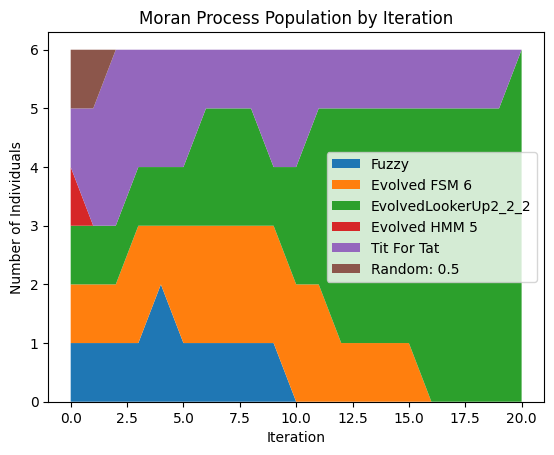

Krećem 2. iteraciju


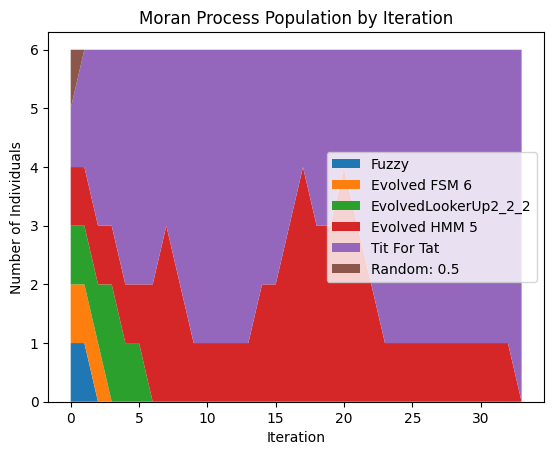

Krećem 3. iteraciju


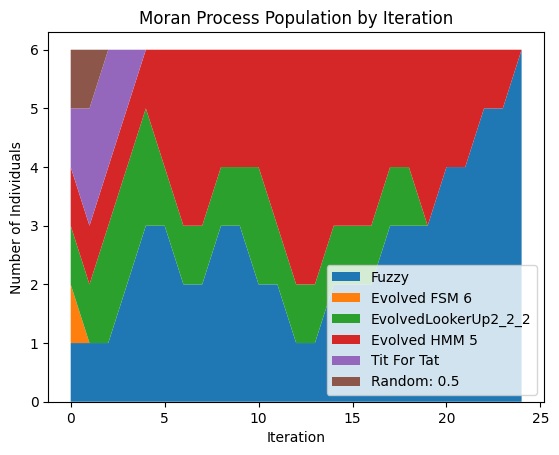

Krećem 4. iteraciju


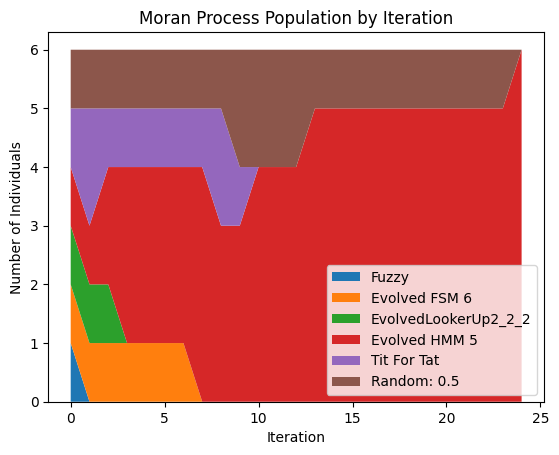

Krećem 5. iteraciju


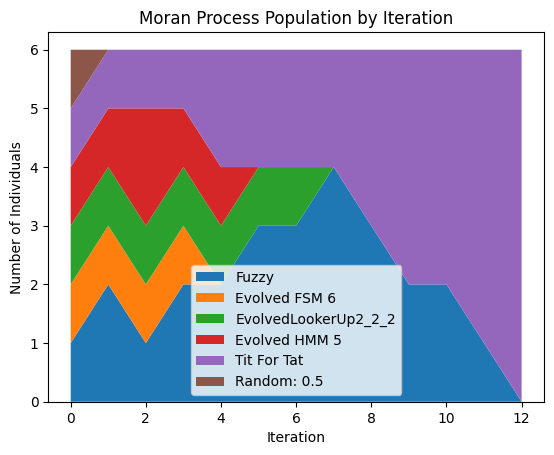

Krećem 6. iteraciju


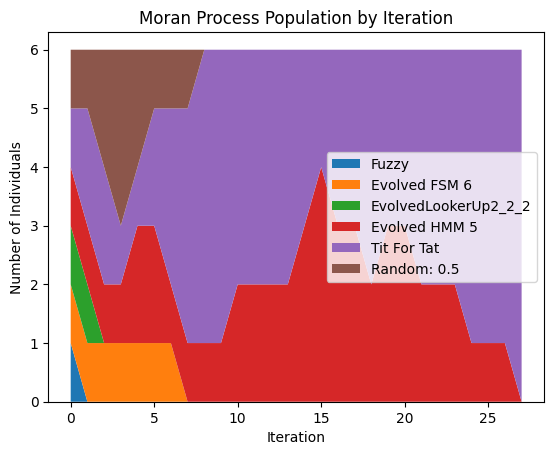

Krećem 7. iteraciju


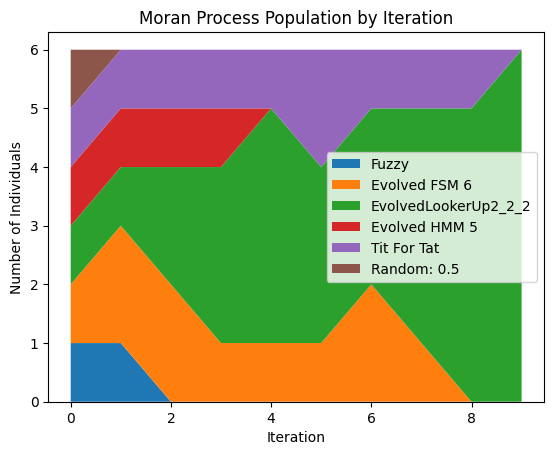

Krećem 8. iteraciju


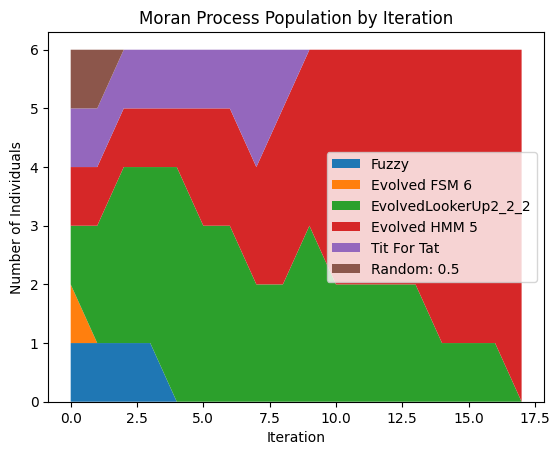

Krećem 9. iteraciju


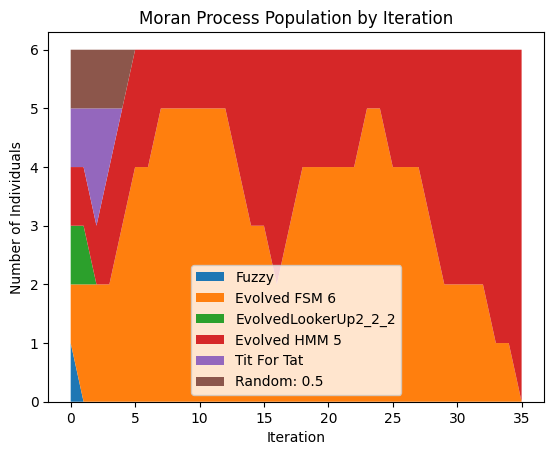

Krećem 10. iteraciju


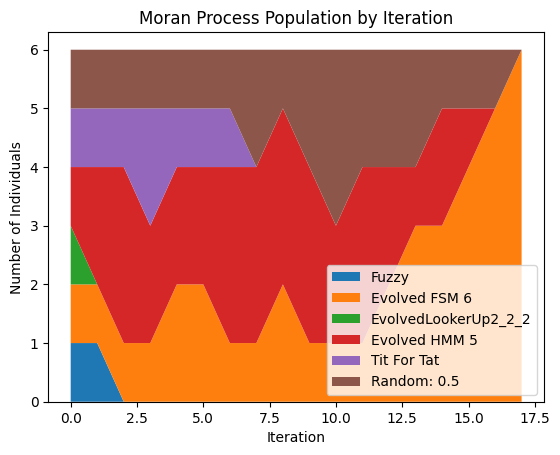

Krećem 11. iteraciju


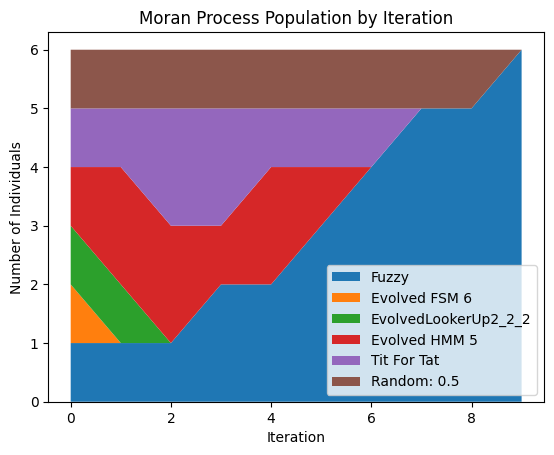

Krećem 12. iteraciju


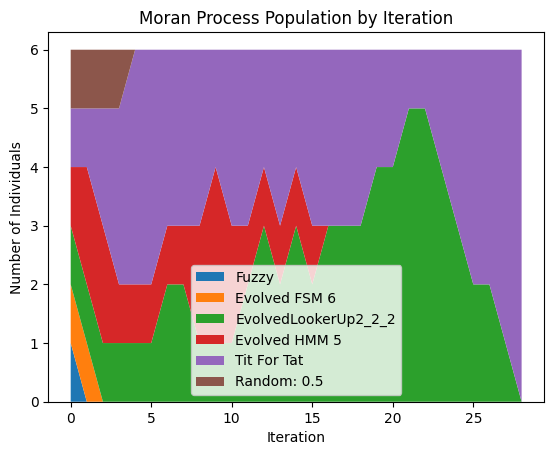

Krećem 13. iteraciju


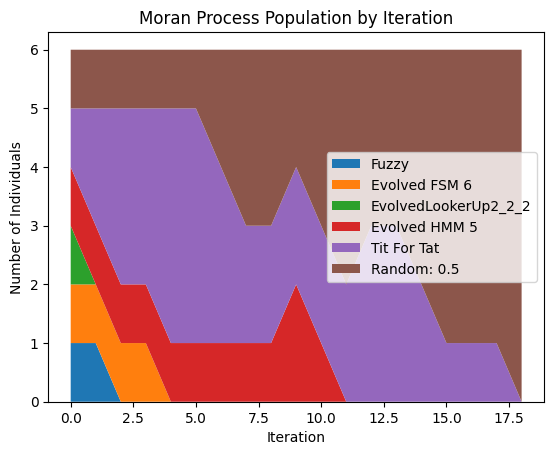

Krećem 14. iteraciju


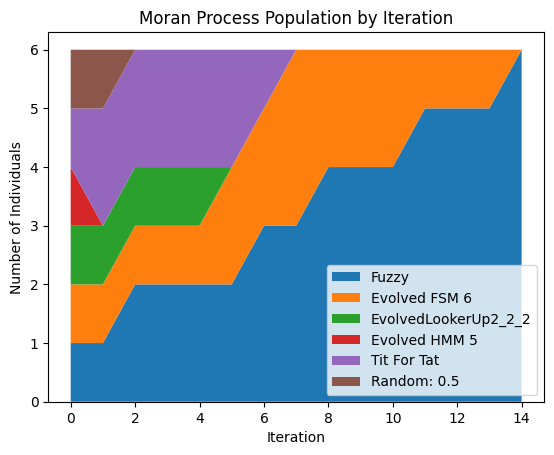

Krećem 15. iteraciju


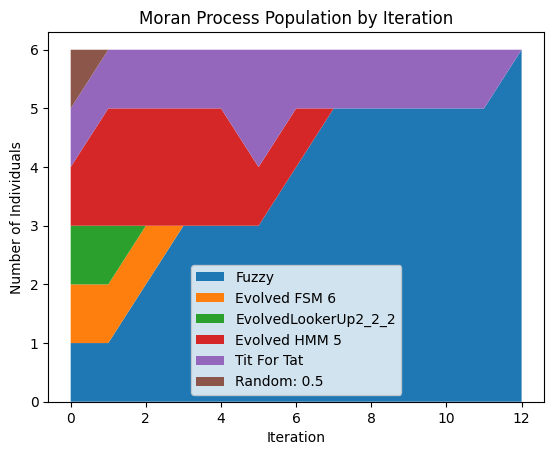

Krećem 16. iteraciju


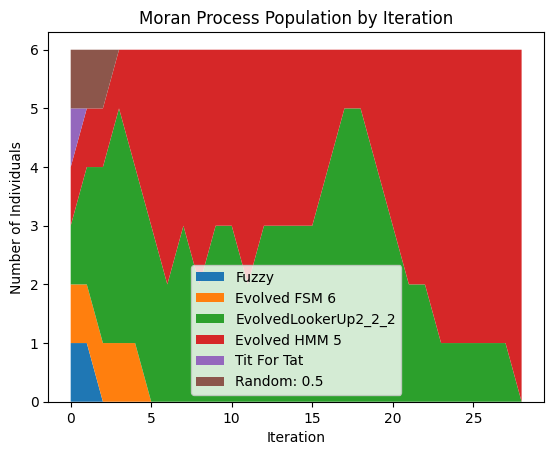

Krećem 17. iteraciju


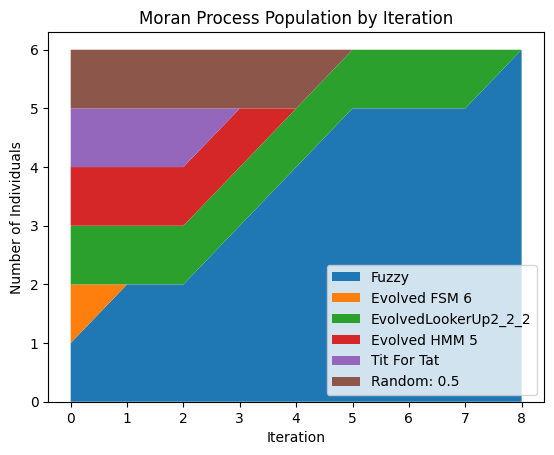

Krećem 18. iteraciju


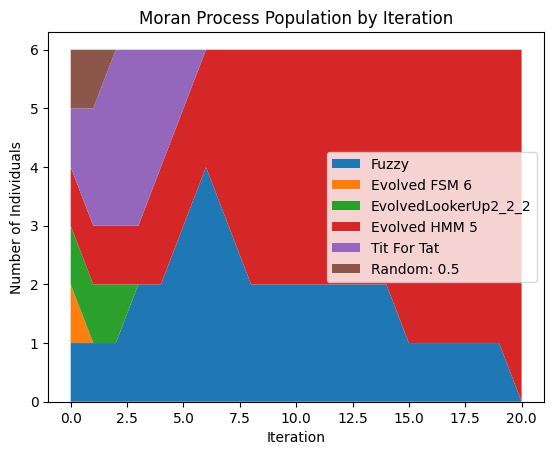

Krećem 19. iteraciju


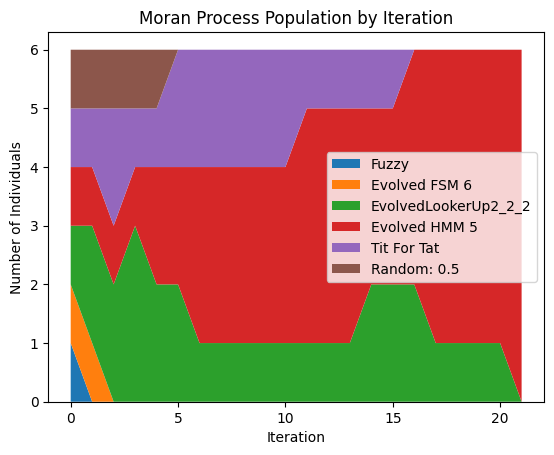

Krećem 20. iteraciju


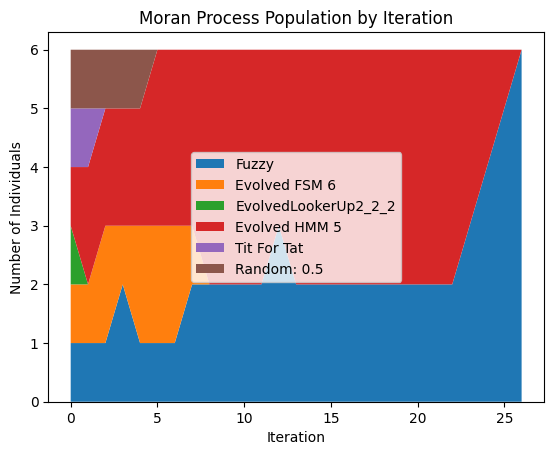

Krećem 21. iteraciju


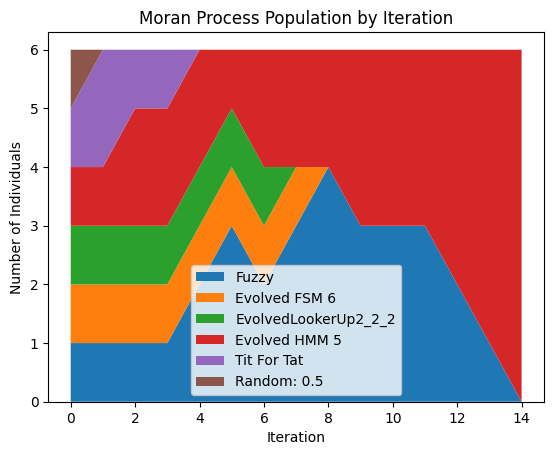

Krećem 22. iteraciju


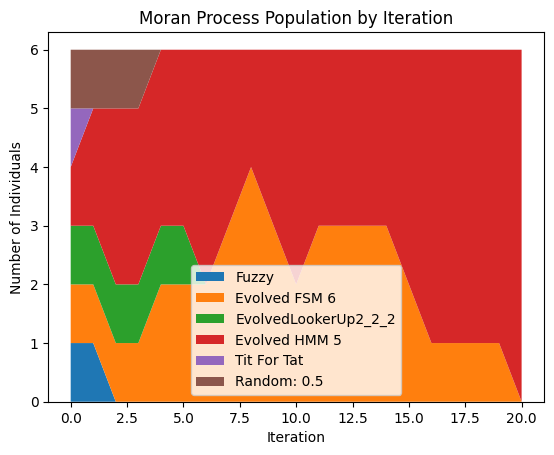

Krećem 23. iteraciju


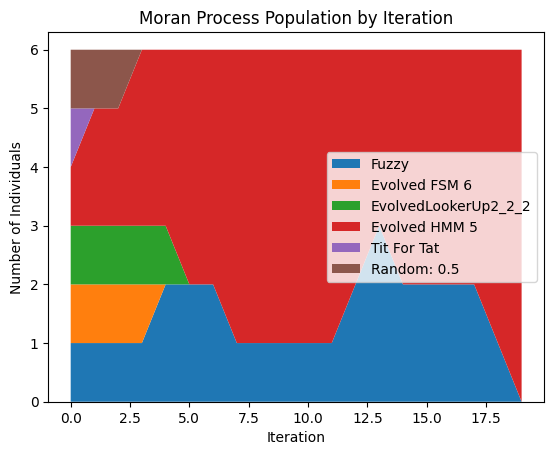

Krećem 24. iteraciju


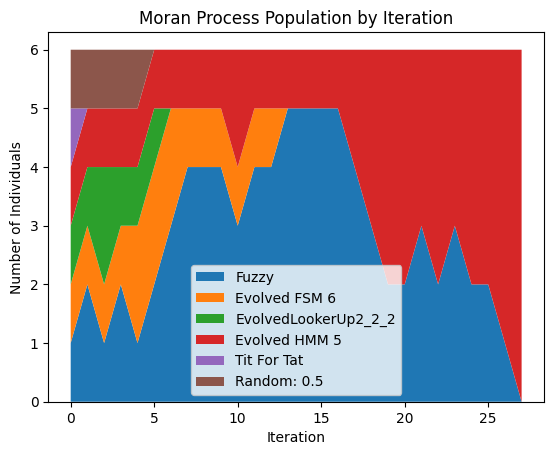

Krećem 25. iteraciju


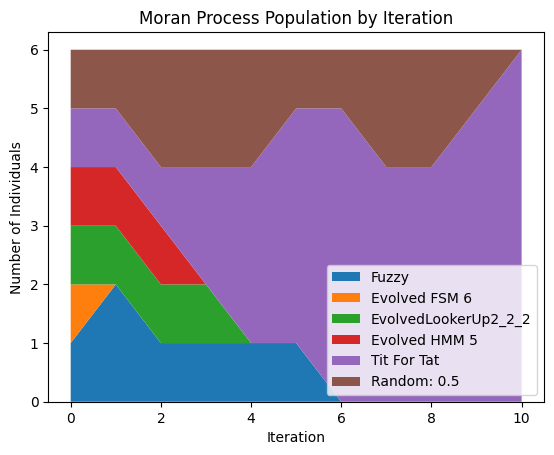

Krećem 26. iteraciju


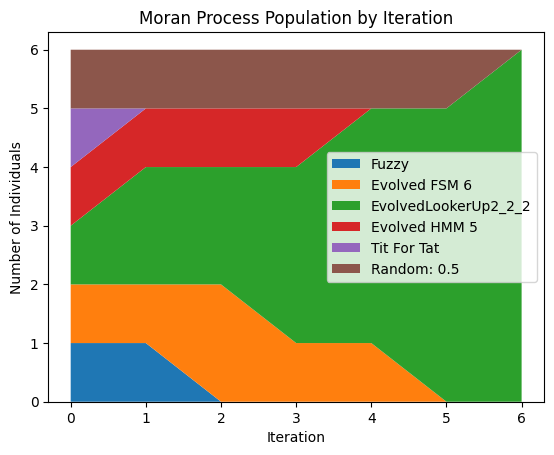

Krećem 27. iteraciju


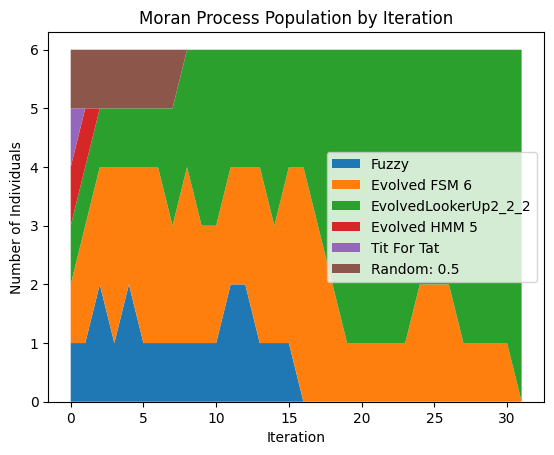

Krećem 28. iteraciju


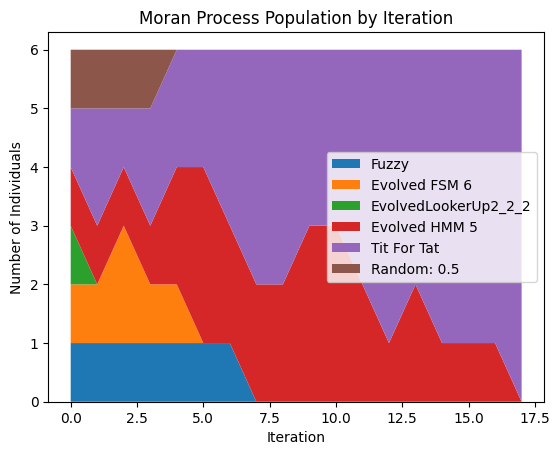

Krećem 29. iteraciju


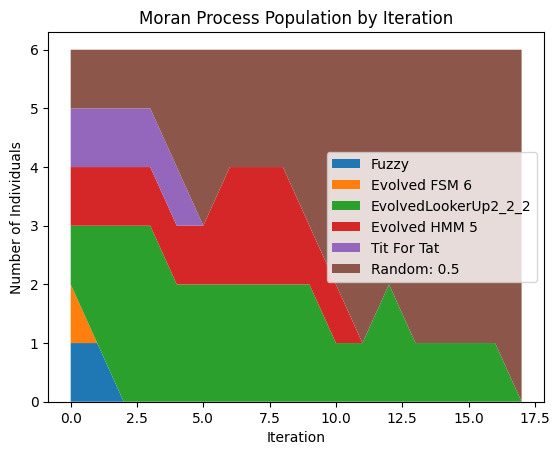

Krećem 30. iteraciju


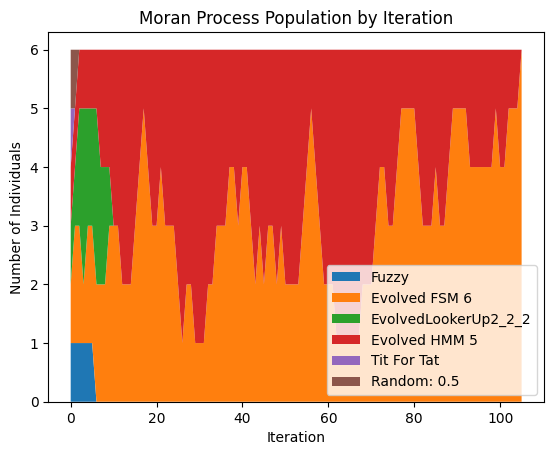

Krećem 31. iteraciju


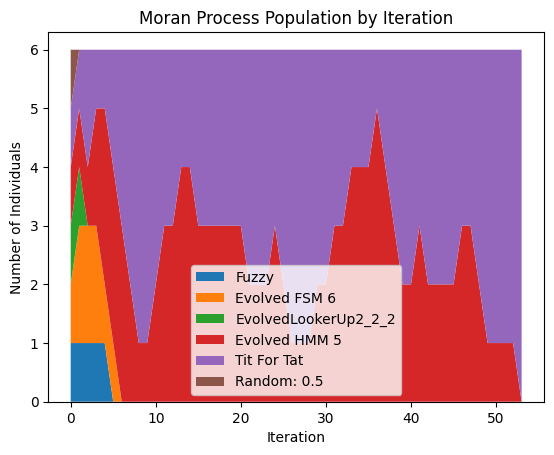

Krećem 32. iteraciju


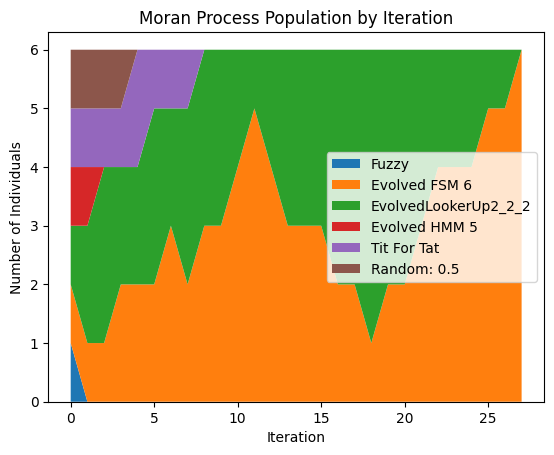

Krećem 33. iteraciju


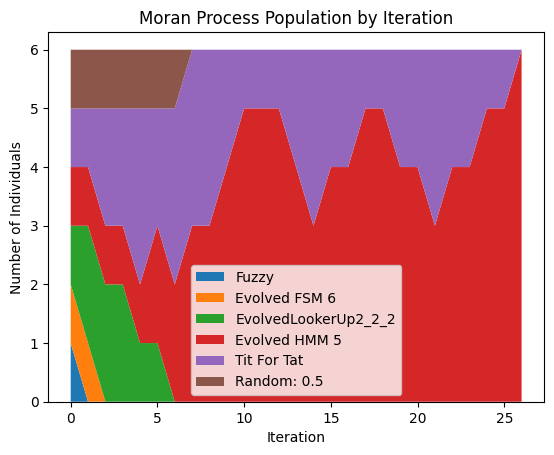

Krećem 34. iteraciju


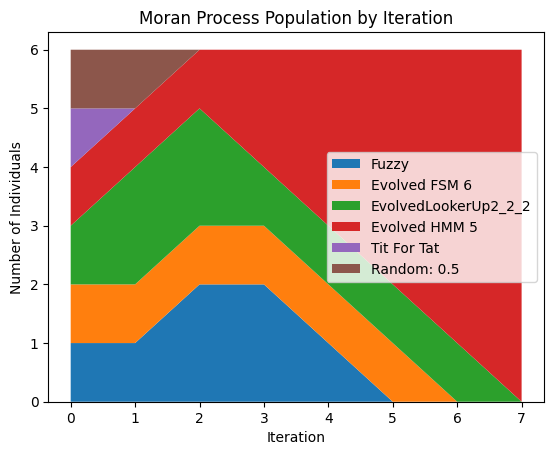

Krećem 35. iteraciju


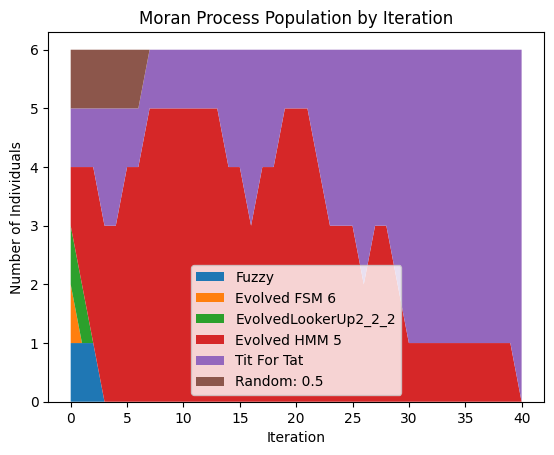

Krećem 36. iteraciju


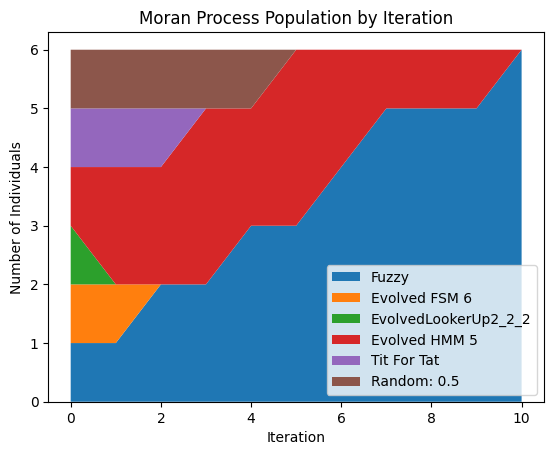

Krećem 37. iteraciju


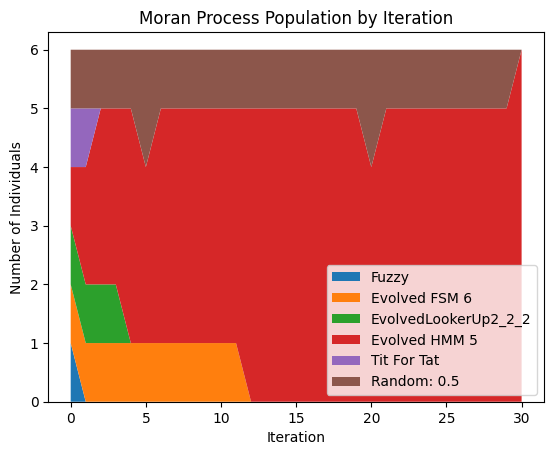

Krećem 38. iteraciju


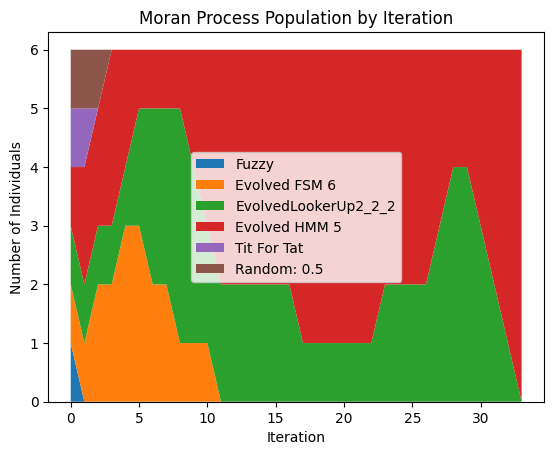

Krećem 39. iteraciju


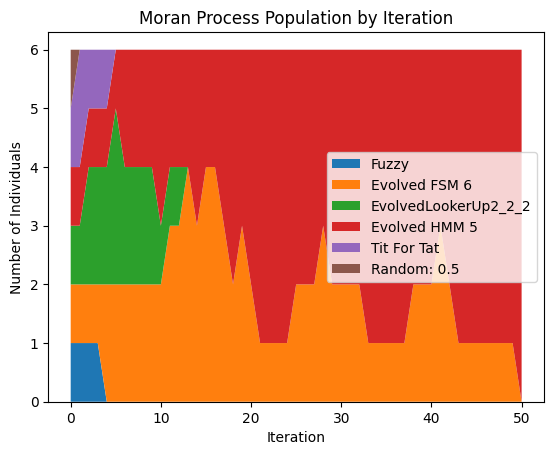

Krećem 40. iteraciju


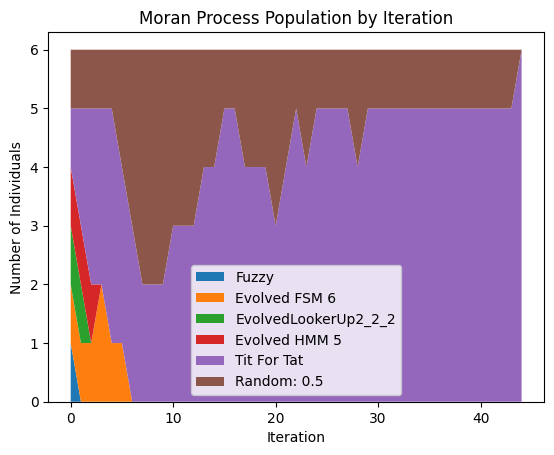

Krećem 41. iteraciju


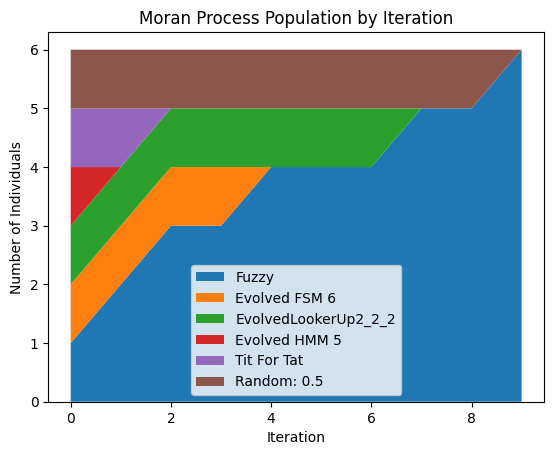

Krećem 42. iteraciju


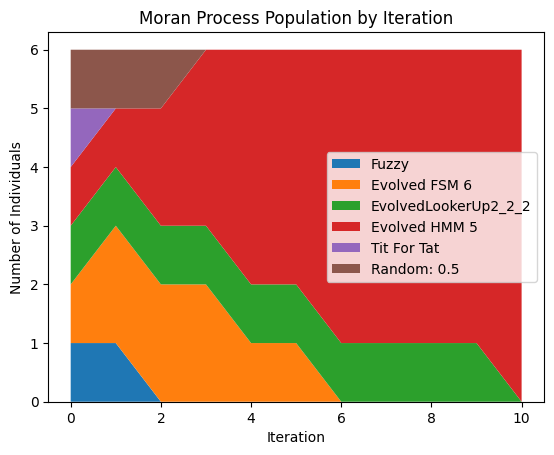

Krećem 43. iteraciju


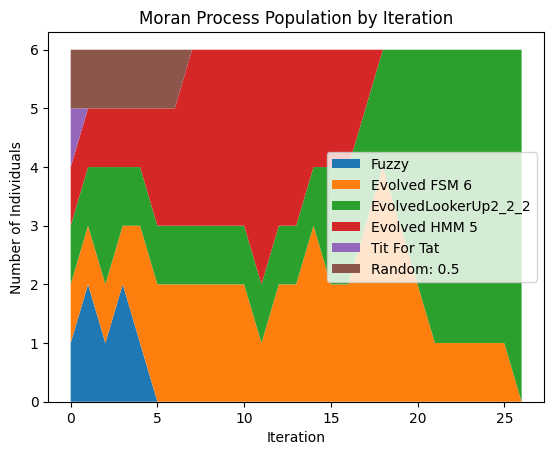

Krećem 44. iteraciju


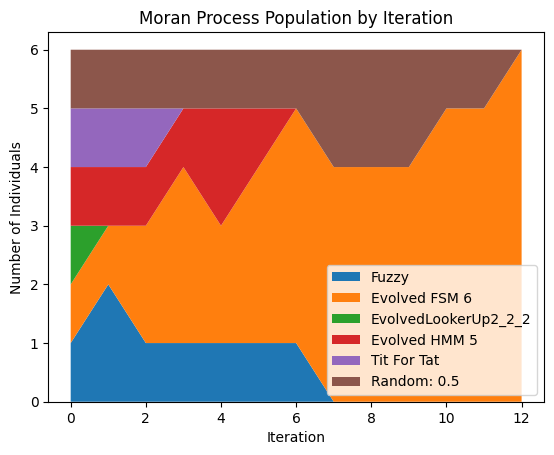

Krećem 45. iteraciju


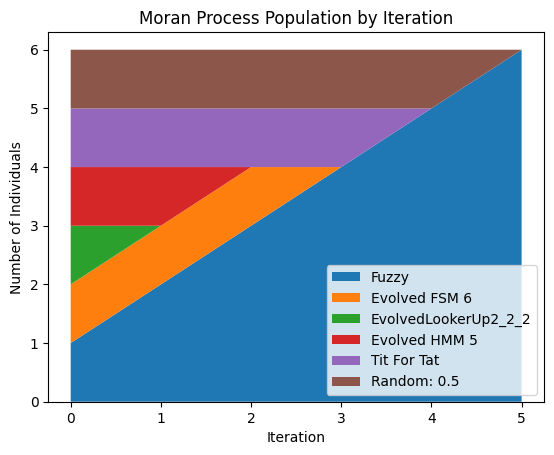

Krećem 46. iteraciju


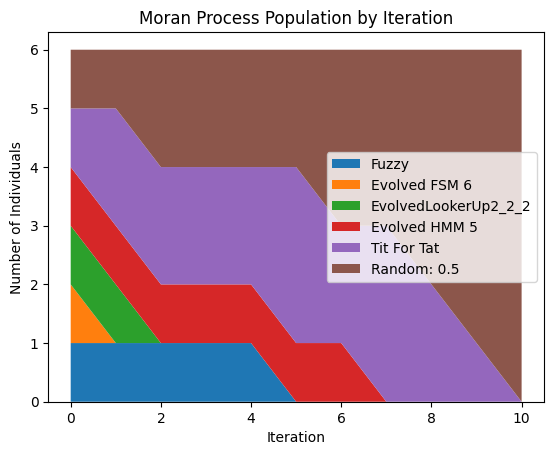

Krećem 47. iteraciju


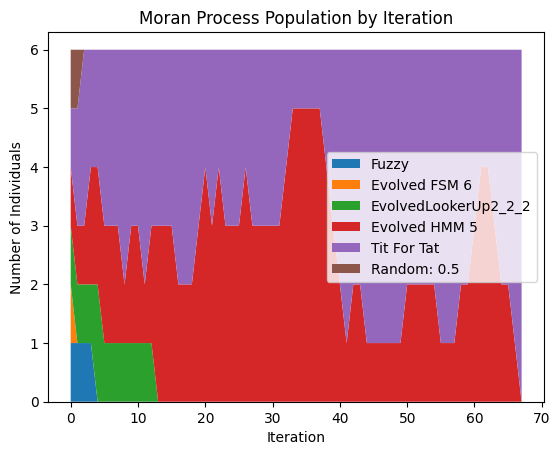

Krećem 48. iteraciju


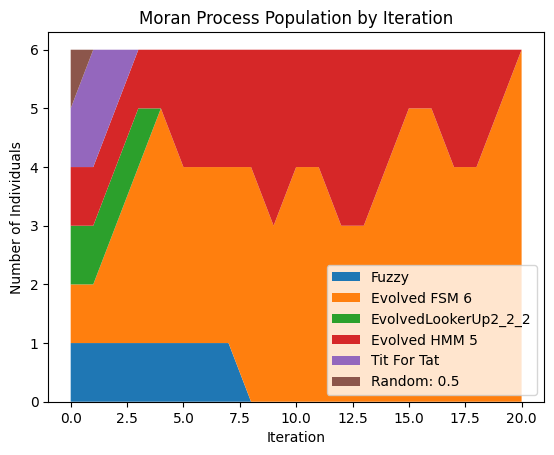

Krećem 49. iteraciju


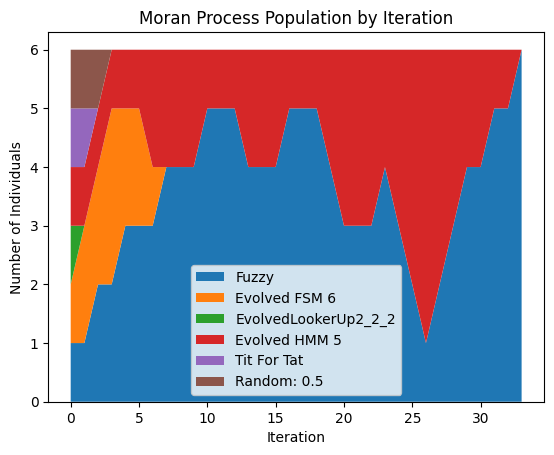

Krećem 50. iteraciju


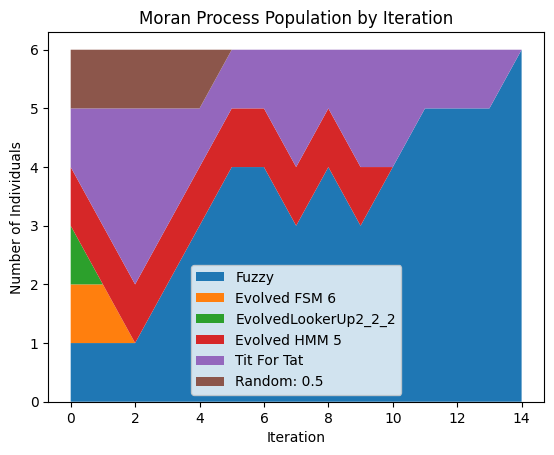

In [2]:
p = [axl.Fuzzy()] + [axl.EvolvedFSM6()] + [axl.EvolvedLookerUp2_2_2()] + [axl.EvolvedHMM5()] + [axl.TitForTat()] + [axl.Random()]

winners = []
dfs = []

for i in range(0, 50):
    print(f"Krećem {i+1}. iteraciju")
    mp = axl.MoranProcess(players=p, stop_on_fixation=True, seed=i, mode="db")
    populations = mp.play()
    
    data = [[] for player in p]
    pop = mp.populations
    for i in range (0, len(p)):
        for j in range(0, len(pop)):
            if(p[i].name != 'Random'):
                data[i].append(pop[j][p[i].name])
            else:
                data[i].append(pop[j]['Random: 0.5'])

    df = pd.DataFrame(columns=[i for i in range(1, len(mp.populations)+1)], data=data, index=[player.name for player in p])
    dfs.append(df)

    winners.append(mp.winning_strategy_name)

    ax = mp.populations_plot()
    plt.show()


In [3]:
unique_winners = set(winners)

winners_df = pd.DataFrame()

for uw in unique_winners:
    winners_df.loc[uw, "Name"] = uw
    winners_df.loc[uw, "%"] = winners.count(uw) / len(winners)

In [4]:
survival = []
for df in dfs:
    last_pos_col = (
    df.gt(0)                      # step 1
    .iloc[:, ::-1]              # step 2 – reverse the columns
    .apply(                     # step 3
        lambda r: r.idxmax()/df.columns[-1] if r.any() else 0,
        axis=1
        )
    )
    survival.append(last_pos_col)

df = pd.concat(survival, axis=1)

# Optionally rename the columns
df.columns = [f"Moran {i+1}" for i in range(len(survival))]

with pd.ExcelWriter(f"Moran 6 najznačajnijih db.xlsx") as writer:
    winners_df.to_excel(writer, sheet_name="Winner rates", startrow=0)
    df.to_excel(writer, sheet_name="Survival rates", startrow=0)
